In [5]:
import sys

# Install all required packages into the current notebook kernel
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost==2.1.4


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /usr/local/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv("Country-data.csv")

In [10]:

df.shape

(167, 10)

In [11]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [12]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [14]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [15]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [16]:
dictionary = pd.read_csv("data-dictionary.csv")

dictionary

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [17]:
dictionary.shape

(10, 2)

In [18]:
dictionary.head()

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...


# Exploratory Data Analysis (EDA)

The objective of this analysis is to understand the distribution of socio-economic indicators and identify relationships between variables before applying clustering and classification algorithms.

In [19]:
df.select_dtypes(include=np.number).columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

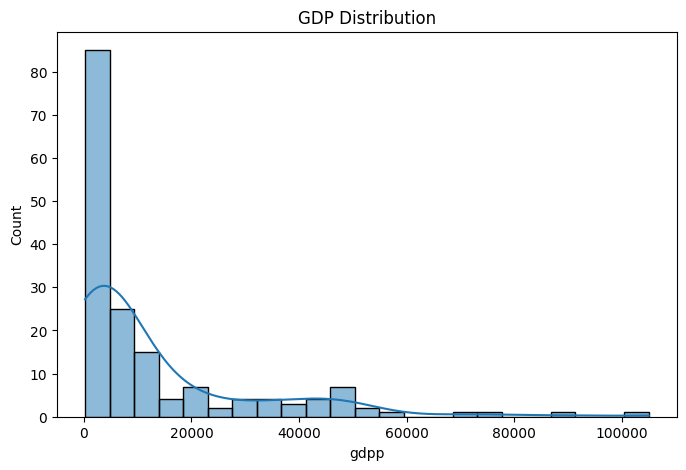

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['gdpp'], kde=True)
plt.title("GDP Distribution")
plt.show()

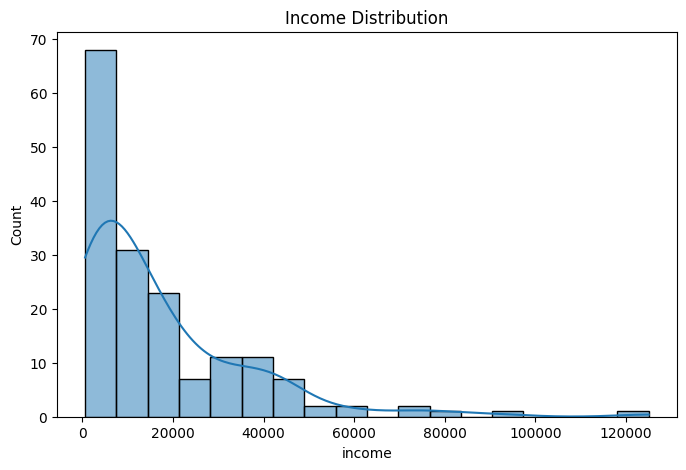

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['income'], kde=True)

plt.title("Income Distribution")

plt.show()

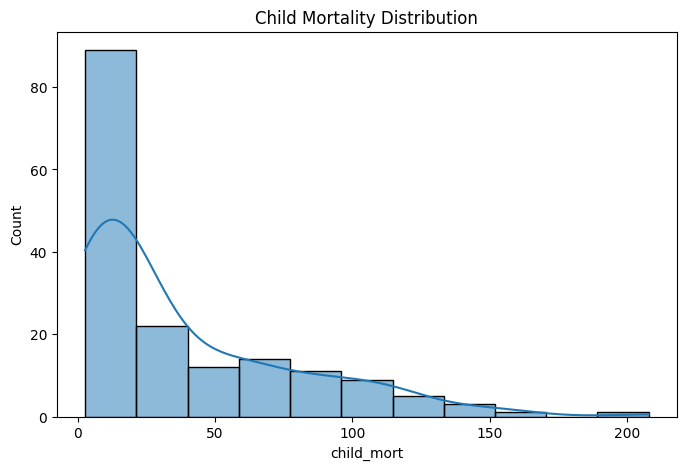

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['child_mort'], kde=True)

plt.title("Child Mortality Distribution")

plt.show()

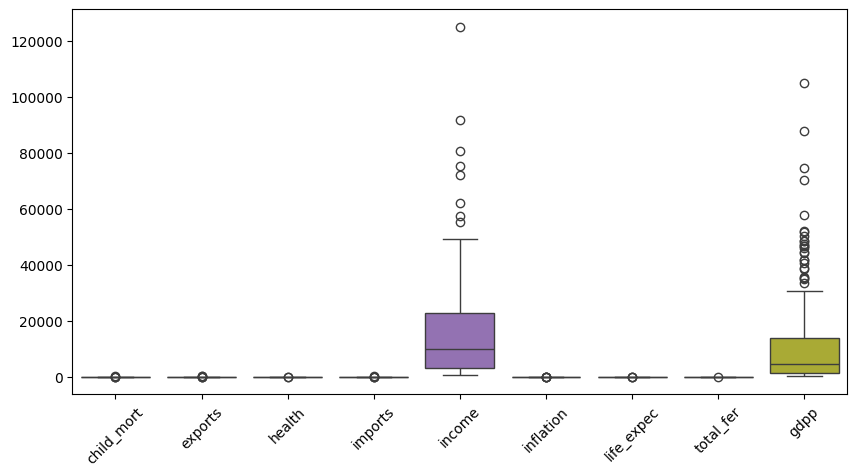

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df.drop('country', axis=1))

plt.xticks(rotation=45)

plt.show()

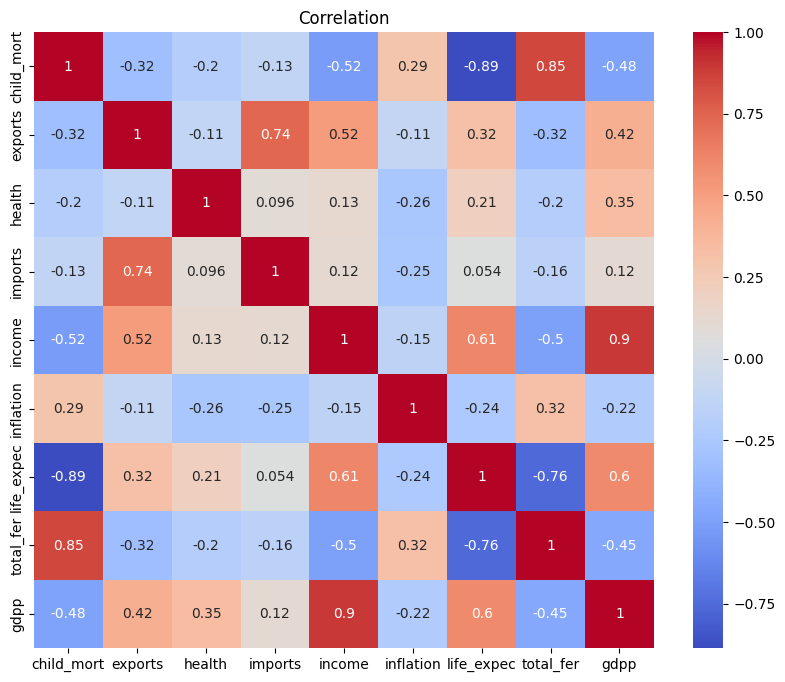

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation")

plt.show()

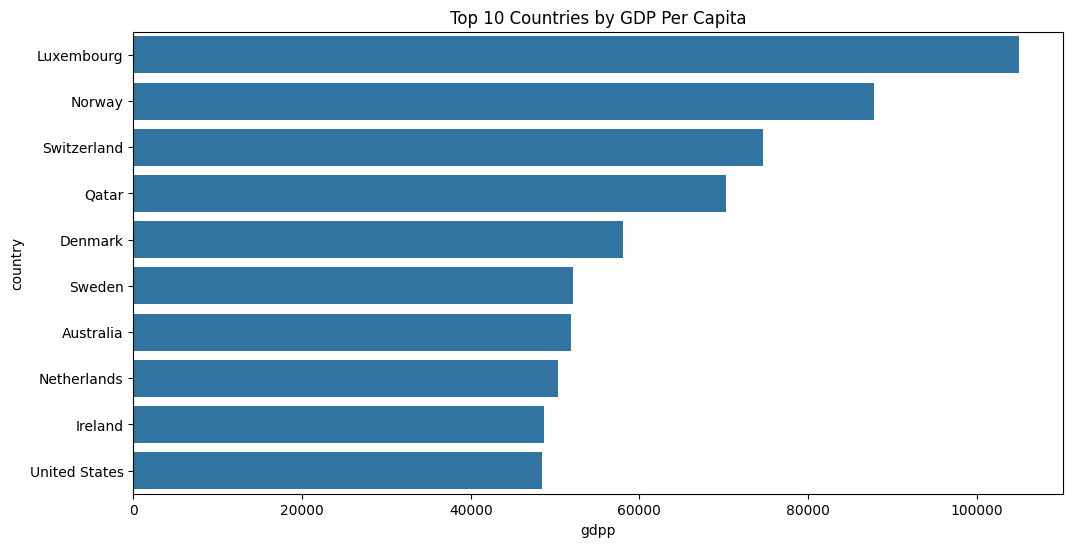

In [25]:
top_gdp = df.sort_values(
    by='gdpp',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_gdp,
    x='gdpp',
    y='country'
)

plt.title("Top 10 Countries by GDP Per Capita")

plt.show()

# K-Means Clustering

K-Means clustering is used to group countries with similar socio-economic characteristics.

In [26]:
from sklearn.preprocessing import StandardScaler

X = df.drop('country', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(167, 9)

In [27]:
pd.DataFrame(X_scaled).describe()

,0,1,2,3,4,5,6,7,8
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-3.722904e-17,2.127373e-16,5.504579e-16,2.765585e-16,-7.977650e-17,-1.063687e-17,3.696311e-16,3.044803e-16,5.850277e-17
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-8.871383e-01,-1.500192e+00,-1.827827e+00,-1.939940e+00,-8.603259e-01,-1.137852e+00,-4.337186e+00,-1.191250e+00,-6.968005e-01
25%,-7.466190e-01,-6.333367e-01,-6.922106e-01,-6.914785e-01,-7.174558e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-6.366596e-01
50%,-4.717981e-01,-2.235279e-01,-1.810007e-01,-1.487432e-01,-3.738080e-01,-2.269504e-01,2.869576e-01,-3.564309e-01,-4.544309e-01
75%,5.926666e-01,3.747198e-01,6.515412e-01,4.913530e-01,2.942370e-01,2.816364e-01,7.042584e-01,6.175252e-01,5.942100e-02
max,4.221297e+00,5.813835e+00,4.047436e+00,5.266181e+00,5.611542e+00,9.129718e+00,1.380962e+00,3.009349e+00,5.036507e+00


In [28]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

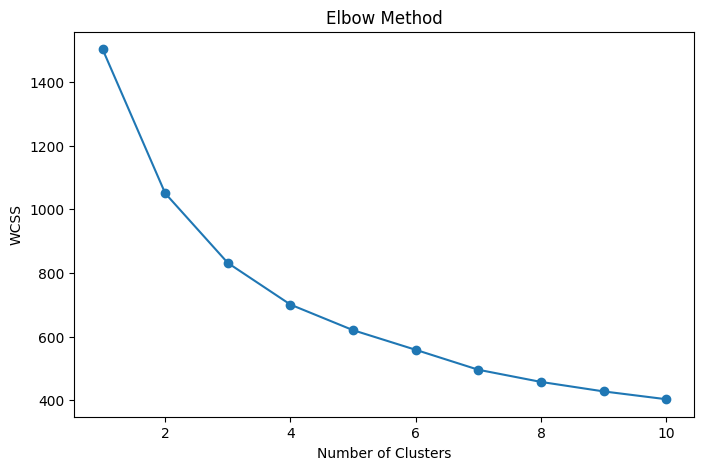

In [29]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [30]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [31]:
df['Cluster'].value_counts()

Cluster
2    84
1    47
0    36
Name: count, dtype: int64

In [32]:
df[['country','Cluster']].head(20)

,country,Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


# PCA Visualization of Clusters

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = clusters

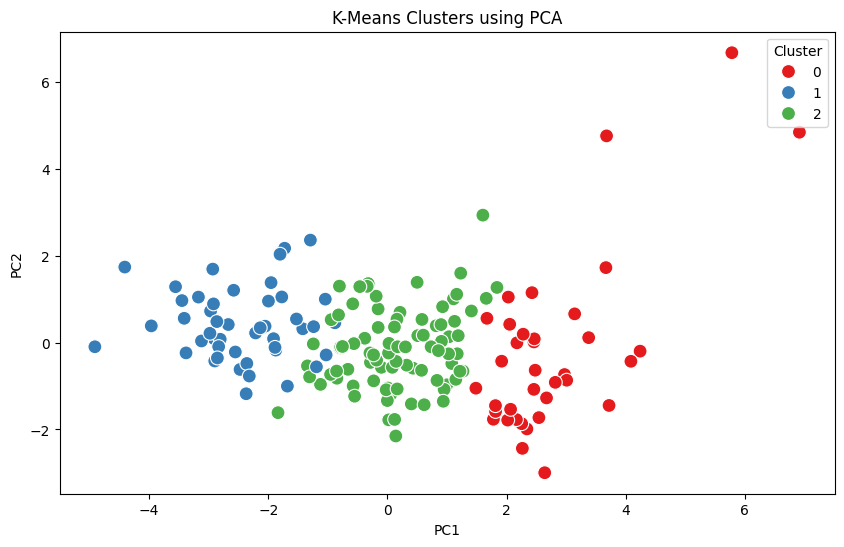

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("K-Means Clusters using PCA")

plt.show()

In [35]:
cluster_summary = df.groupby('Cluster').mean(
    numeric_only=True
)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


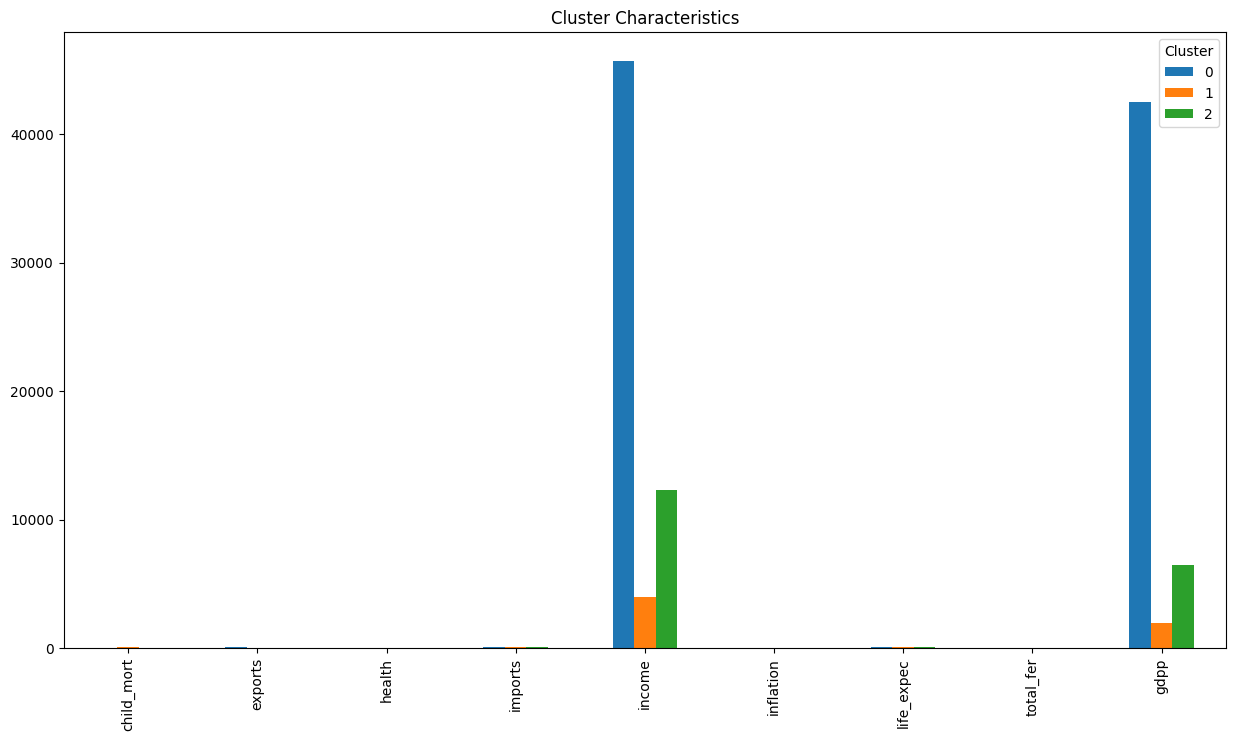

In [36]:
cluster_summary.T.plot(
    kind='bar',
    figsize=(15,8)
)
plt.title("Cluster Characteristics")

plt.show()

In [37]:
df.groupby('Cluster').size()

Cluster
0    36
1    47
2    84
dtype: int64

In [38]:
df[df['Cluster']==0][['country']]

,country
7,Australia
8,Austria
11,Bahrain
15,Belgium
23,Brunei
29,Canada
42,Cyprus
43,Czech Republic
44,Denmark
53,Finland


In [39]:
df[df['Cluster']==1][['country']]

,country
0,Afghanistan
3,Angola
17,Benin
21,Botswana
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic
32,Chad
36,Comoros


In [40]:
df[df['Cluster']==2][['country']]

,country
1,Albania
2,Algeria
4,Antigua and Barbuda
5,Argentina
6,Armenia
...,...
160,Uruguay
161,Uzbekistan
162,Vanuatu
163,Venezuela


In [41]:
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


# DBSCAN Clustering


In [42]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
db_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

In [43]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

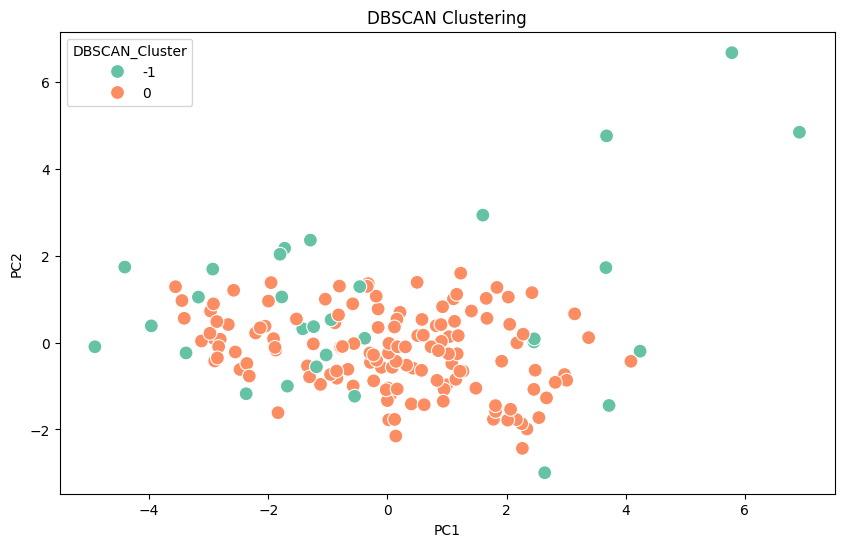

In [44]:
pca_df['DBSCAN_Cluster'] = db_clusters
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='Set2',
    s=100
)
plt.title("DBSCAN Clustering")
plt.show()

In [45]:
y = df['Cluster']
X = df.drop(
    columns=[
        'country',
        'Cluster',
        'DBSCAN_Cluster' ])
print(X.shape)
print(y.shape)

(167, 9)
(167,)


In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(
    y_test,
    dt_pred
))

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.90      0.95        10
           2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34



In [48]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(
    y_test,
    rf_pred
))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [49]:
!pip install xgboost -q

zsh:1: command not found: pip


In [50]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(
    y_test,
    xgb_pred
))

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



In [51]:
results = pd.DataFrame({
    'Model':['Decision Tree',
        'Random Forest',
        'XGBoost'],
    'Accuracy':[
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]})
results

,Model,Accuracy
0,Decision Tree,0.941176
1,Random Forest,1.000000
2,XGBoost,0.941176


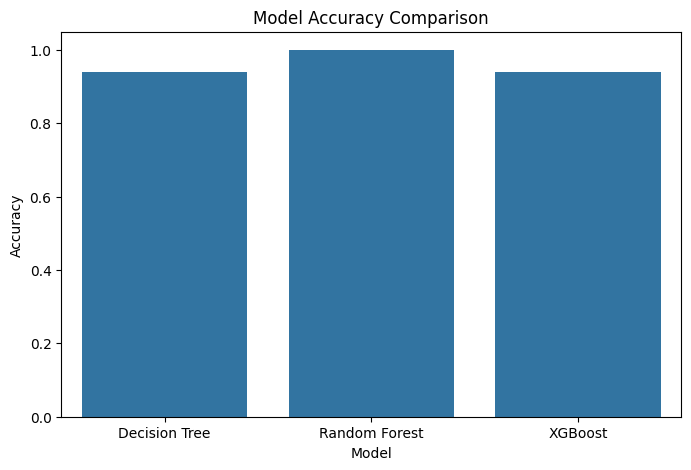

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)
plt.title("Model Accuracy Comparison")

plt.show()

In [53]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
0,child_mort,0.261935
8,gdpp,0.202125
7,total_fer,0.165920
6,life_expec,0.156307
4,income,0.146203
2,health,0.030472
5,inflation,0.014817
3,imports,0.012632
1,exports,0.009589


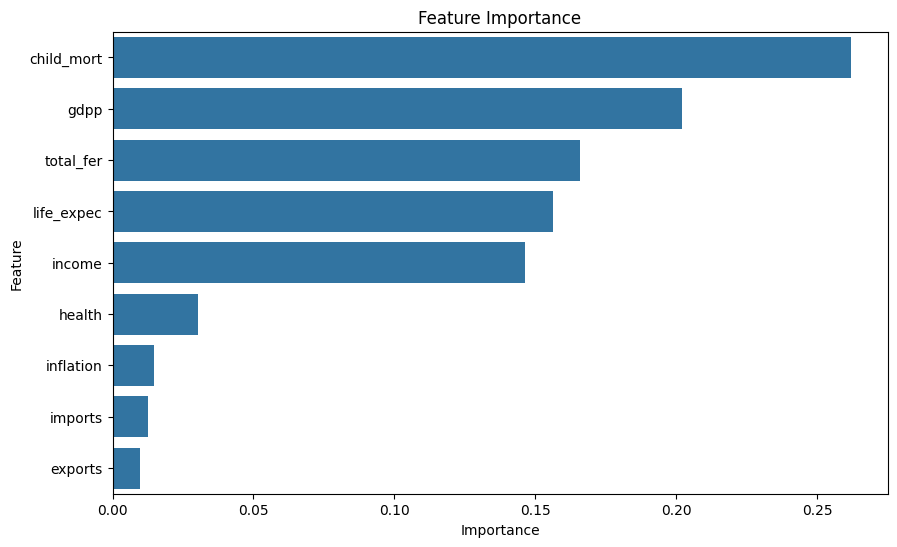

In [54]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature')
plt.title("Feature Importance")
plt.show()

In [55]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
0,child_mort,0.261935
8,gdpp,0.202125
7,total_fer,0.165920
6,life_expec,0.156307
4,income,0.146203
2,health,0.030472
5,inflation,0.014817
3,imports,0.012632
1,exports,0.009589


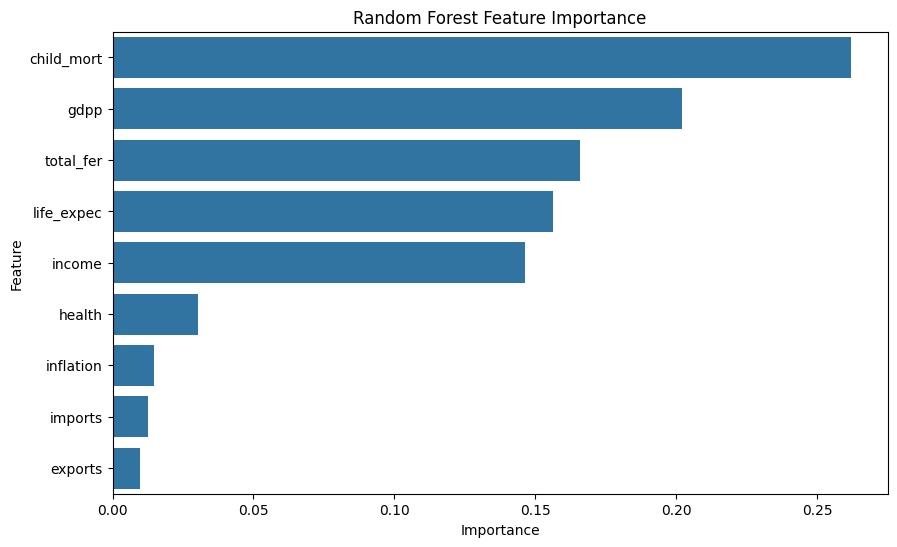

In [56]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Random Forest Feature Importance")

plt.show()

#Hyperparameter tuning

In [57]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 3, 'n_estimators': 100}
0.9396011396011398


In [58]:
best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)
print(
    accuracy_score(
        y_test,
        best_pred))

0.9411764705882353


In [59]:
results = pd.DataFrame({
    'Model':[
        'Decision Tree',
        'Random Forest',
        'XGBoost'],
    'Accuracy':[
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)]})
results

,Model,Accuracy
0,Decision Tree,0.941176
1,Random Forest,1.000000
2,XGBoost,0.941176


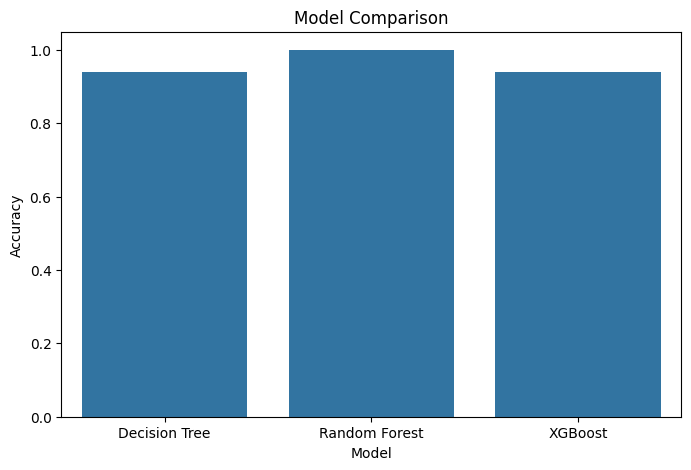

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x='Model',
    y='Accuracy')
plt.title("Model Comparison")
plt.show()